# Reading and subetting organoid atlas dataset - HNOCA extended

[Reference paper](https://www.nature.com/articles/s41586-024-08172-8)

## 1. Environment Set Up

### 1.1 Library upload

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import igraph as ig
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix, isspmatrix
from datetime import datetime
import sys
sys.path.append('../')
import functions as fn

print(np.__version__)
print(pd.__version__)
print(sc.__version__)


1.26.4
2.2.2
1.10.2


In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100)

### 1.2 Starting computations: timestamp

In [4]:
print(datetime.now())

2026-03-05 14:56:32.623515


## 2. Read input files

Download details: https://datasets.cellxgene.cziscience.com/aea3d8eb-82a7-4479-b902-3cca4c9300ee.h5ad

In [5]:
adata_complete = sc.read('../../../../DataDir/scRNASeq/HNOCA/cellxgene/data.h5ad')

In [6]:
adata_complete

AnnData object with n_obs × n_vars = 1920454 × 35725
    obs: 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type_original', 'gm', 'id', 'individual', 'state_exact', 'suspension_type', 'tech_sample', 'treatment', 'organoid_age_days', 'publication', 'doi', 'batch', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis', 'hnoca_core', 'annot_level_2_extended', 'tissue_type', 'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_length', 'highly_variable', 'highly_variable_rank', 'highly_variable_nbatches', 'feature_is_filtered', 'feature_name'

In [7]:
adata_complete.var

,gene_length,highly_variable,highly_variable_rank,highly_variable_nbatches,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000000003,3796,False,2243.0,118,False,TSPAN6,NCBITaxon:9606,gene,2396,protein_coding
ENSG00000000005,1205,True,738.5,114,False,TNMD,NCBITaxon:9606,gene,873,protein_coding
ENSG00000000419,3004,False,2032.0,9,False,DPM1,NCBITaxon:9606,gene,1262,protein_coding
ENSG00000000457,6308,False,2532.0,15,False,SCYL3,NCBITaxon:9606,gene,2916,protein_coding
ENSG00000000460,4355,False,2444.0,37,False,FIRRM,NCBITaxon:9606,gene,2661,protein_coding
...,...,...,...,...,...,...,...,...,...,...
ENSG00000288721,6172,False,NaN,0,False,ENSG00000288721,NCBITaxon:9606,gene,3684,protein_coding
ENSG00000288722,1707,False,2566.5,6,False,F8A1,NCBITaxon:9606,gene,1707,protein_coding
ENSG00000288723,1015,False,NaN,0,False,ENSG00000288723,NCBITaxon:9606,gene,542,lncRNA
ENSG00000288724,625,False,NaN,0,False,ENSG00000288724,NCBITaxon:9606,gene,494,lncRNA


In [8]:
adata_complete.obs.columns

Index(['assay_differentiation', 'assay_type_differentiation', 'bio_sample',
       'cell_line', 'cell_type_original', 'gm', 'id', 'individual',
       'state_exact', 'suspension_type', 'tech_sample', 'treatment',
       'organoid_age_days', 'publication', 'doi', 'batch', 'annot_level_1',
       'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2',
       'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis',
       'hnoca_core', 'annot_level_2_extended', 'tissue_type',
       'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id',
       'disease_ontology_term_id', 'development_stage_ontology_term_id',
       'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')

In [9]:
adata_complete.obs[['organoid_age_days', 'assay_differentiation', 'assay_type_differentiation', 'tissue']]

,organoid_age_days,assay_differentiation,assay_type_differentiation,tissue
new_index,,,,
homosapiens_hindbrain_2020_bdrhapsodywholetranscriptomeanalysis_andersenjimena_001_d10_1016_j_cell_2020_11_017_53_14-44-80,45,"Andersen, 2020 (doi: 10.1016/j.cell.2020.11.017)",guided,hindbrain
homosapiens_hindbrain_2020_bdrhapsodywholetranscriptomeanalysis_andersenjimena_001_d10_1016_j_cell_2020_11_017_69_48-73-96,45,"Andersen, 2020 (doi: 10.1016/j.cell.2020.11.017)",guided,hindbrain
homosapiens_hindbrain_2020_bdrhapsodywholetranscriptomeanalysis_andersenjimena_001_d10_1016_j_cell_2020_11_017_72_19-32-61,45,"Andersen, 2020 (doi: 10.1016/j.cell.2020.11.017)",guided,hindbrain
homosapiens_hindbrain_2020_bdrhapsodywholetranscriptomeanalysis_andersenjimena_001_d10_1016_j_cell_2020_11_017_76_10-13-76,45,"Andersen, 2020 (doi: 10.1016/j.cell.2020.11.017)",guided,hindbrain
homosapiens_hindbrain_2020_bdrhapsodywholetranscriptomeanalysis_andersenjimena_001_d10_1016_j_cell_2020_11_017_78_37-19-8,45,"Andersen, 2020 (doi: 10.1016/j.cell.2020.11.017)",guided,hindbrain
...,...,...,...,...
TTTGTCAGTCCAAGTT-3_ce_giandomenico2019,75,NaN,NaN,brain
TTTGTCAGTCTCCACT-3_ce_giandomenico2019,75,NaN,NaN,brain
TTTGTCAGTTTAGCTG-3_ce_giandomenico2019,75,NaN,NaN,brain


In [10]:
adata_complete.obs['assay_differentiation'].value_counts()

assay_differentiation
Velasco, 2019 (doi: 10.1038/s41586-019-1289-x)                     790295
Yoon, 2019 (doi: 10.1038/s41592-018-0255-0)                        213860
Lancaster, 2014 (doi: 10.1038/nprot.2014.158)                      192890
Fiorenzano, 2021 (doi: 10.1038/s41467-021-27464-5); standard        78612
Quadrato, 2017 (doi: 10.1038/protex.2017.049)                       65256
Jo et al., 2016 (doi: 10.1016/j.stem.2016.07.005)                   59980
Qian et al., 2016 (doi: 10.1016/j.cell.2016.04.032)                 49275
Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0); most directed       45755
Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0); directed            43308
Watanabe, 2017 (doi: 10.1016/j.celrep.2017.09.047)                  27874
Huang, 2021 (doi: 10.1016/j.stem.2021.04.006)                       26693
Pasca, 2015 (doi: 10.1038/nmeth.3415)                               20899
Miura, 2020 (doi: 10.1038/s41587-020-00763-w)                       19011
Pellegrini, 2020

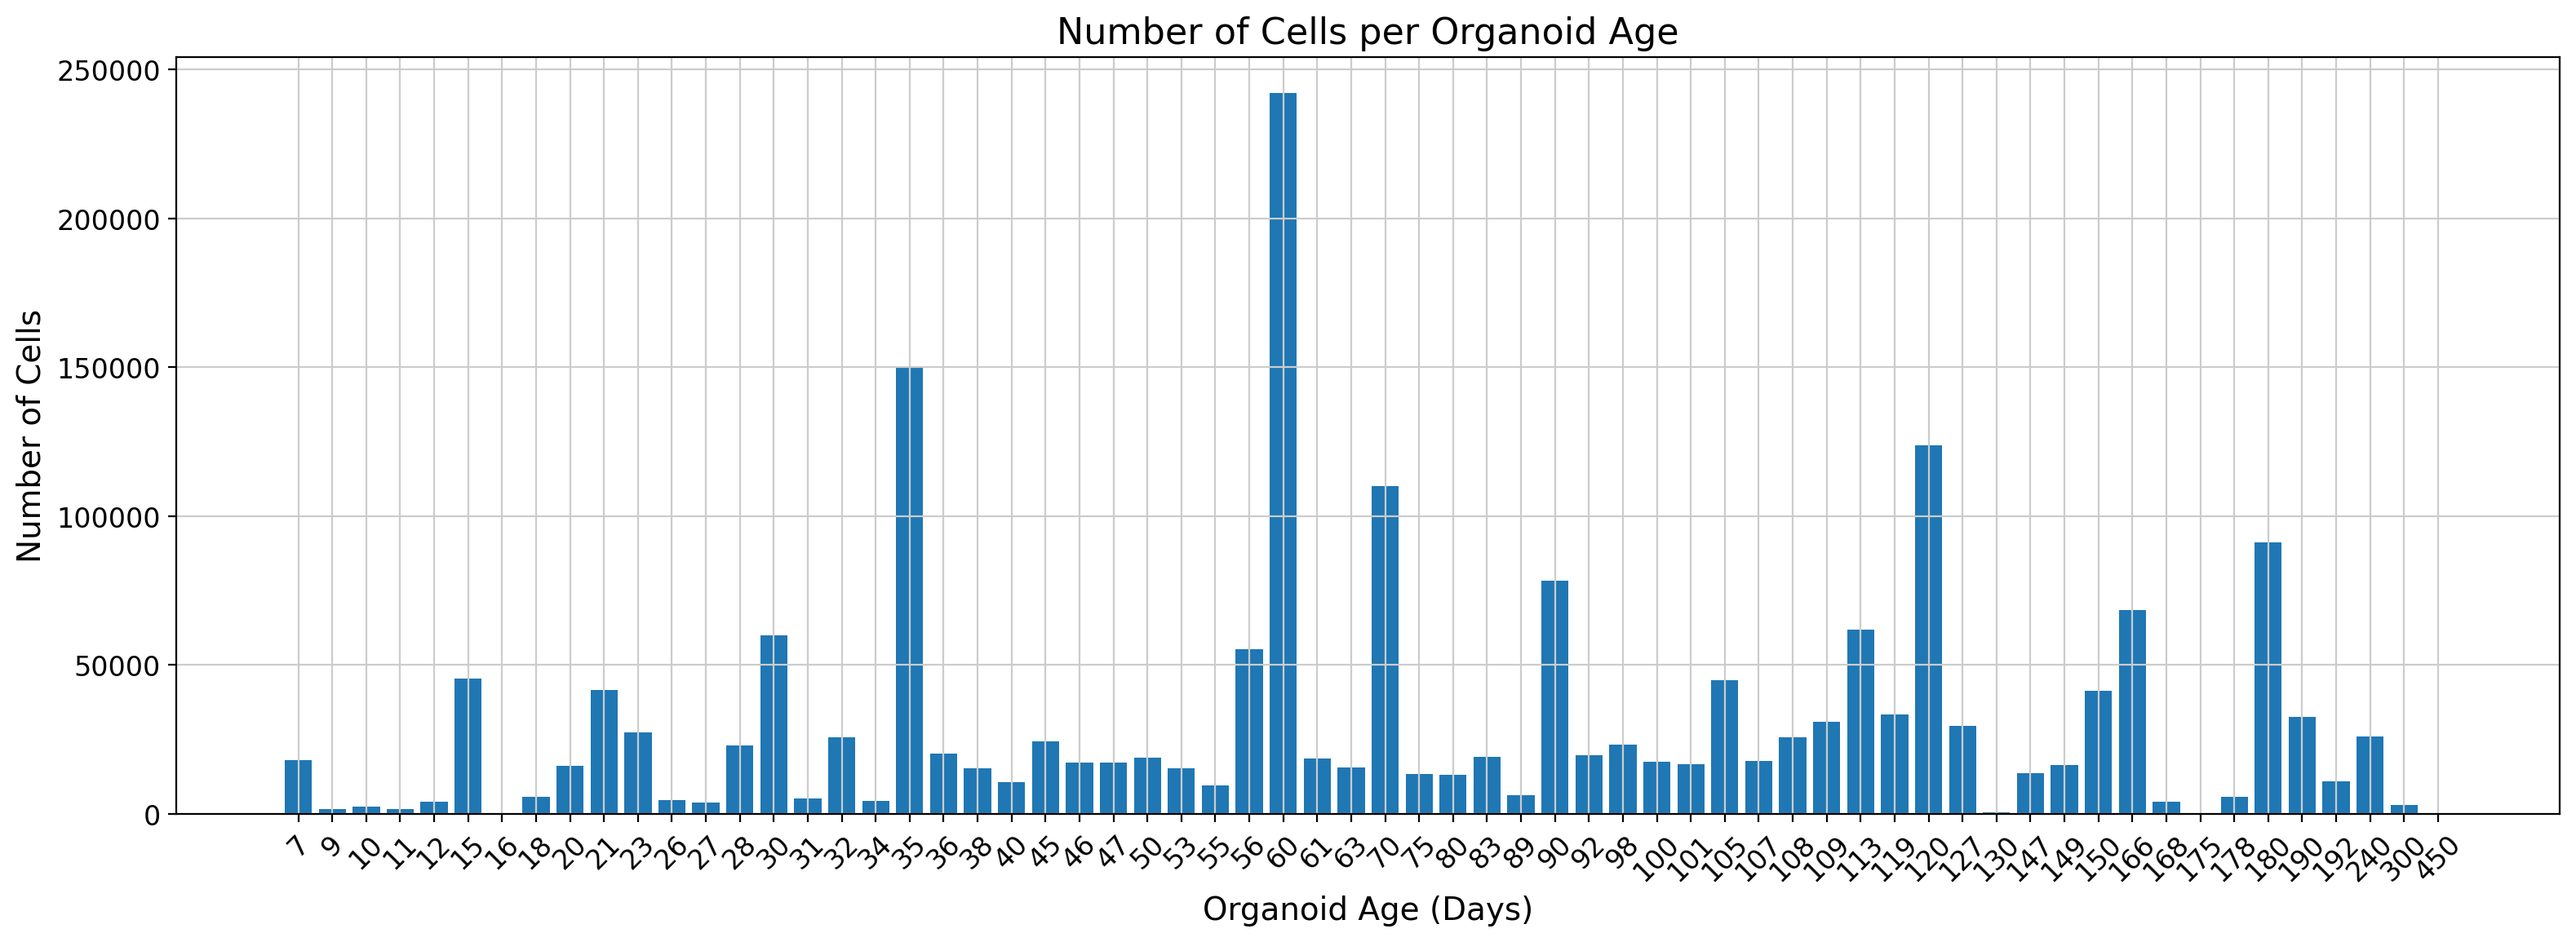

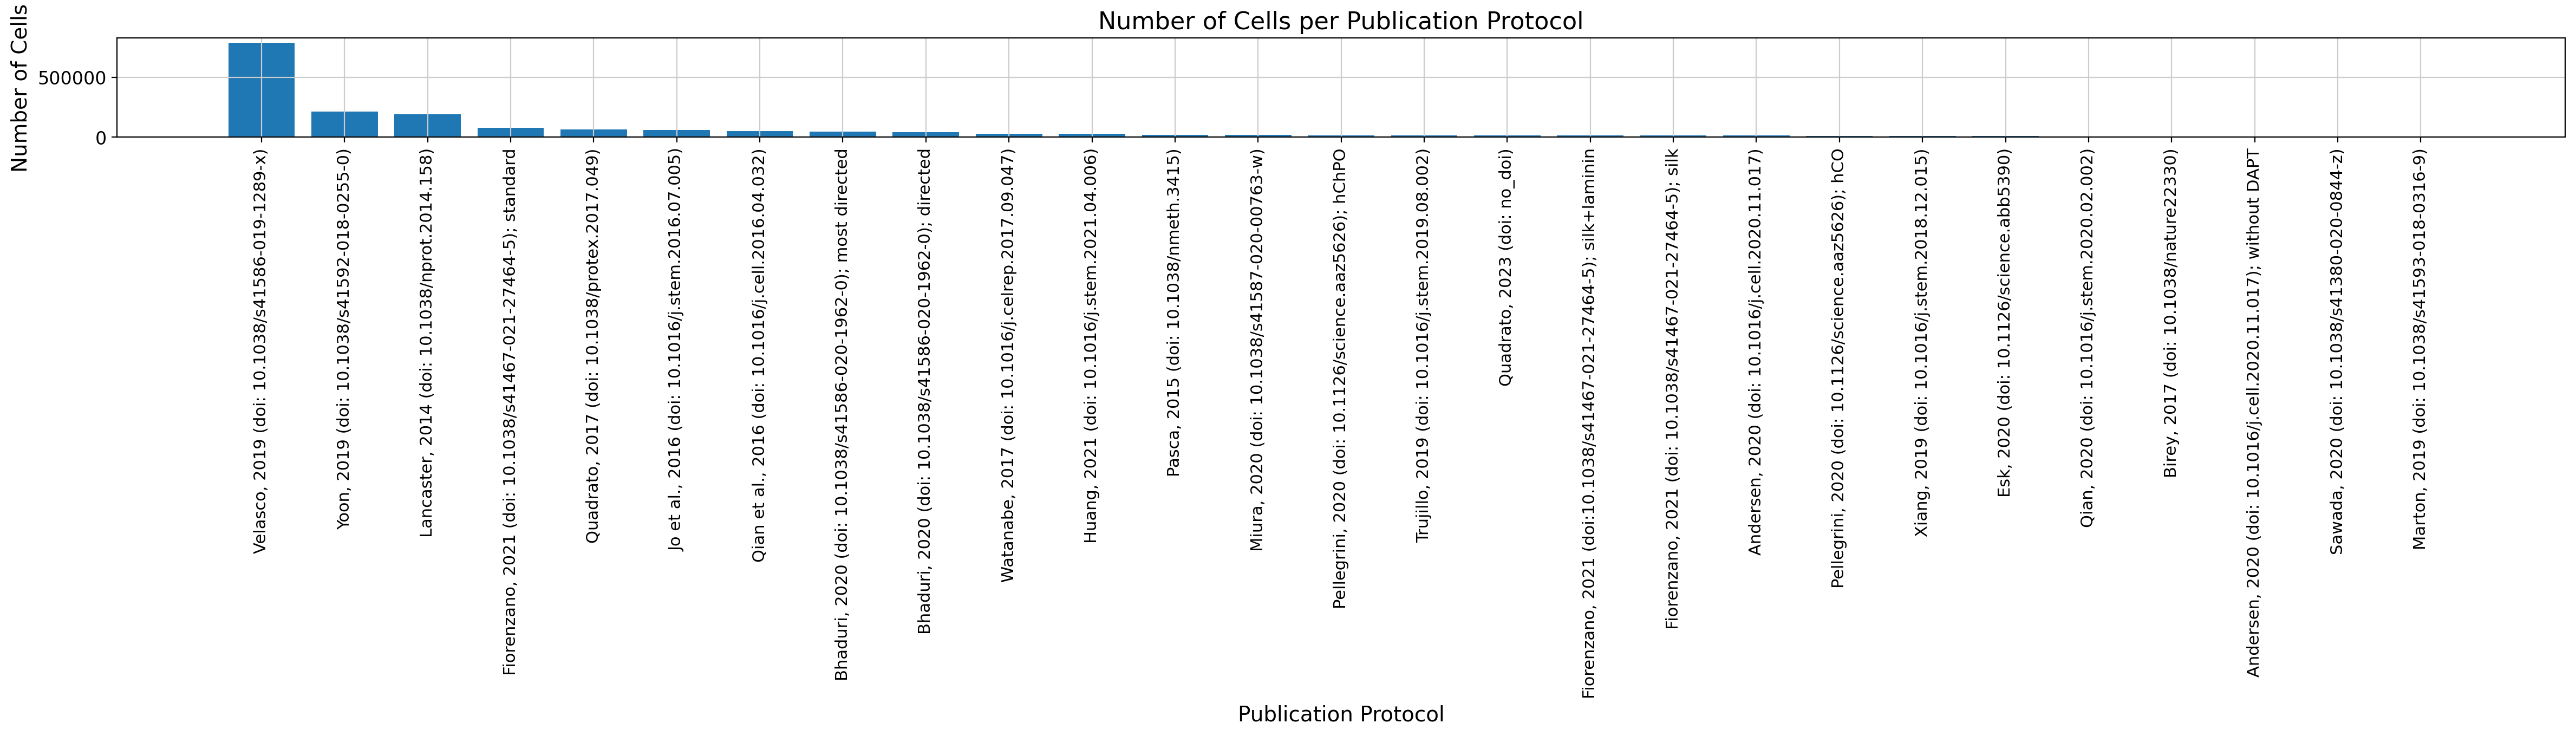

In [14]:
# ---- Barplot 1: Number of cells per organoid age ----
age_counts = (
    adata_complete.obs['organoid_age_days']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 6))  # wider
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.xlabel("Organoid Age (Days)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Organoid Age", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


# ---- Barplot 2: Number of cells per publication protocol ----
protocol_counts = (
    adata_complete.obs['assay_differentiation']
    .value_counts()
)

plt.figure(figsize=(24, 7))  # much wider
plt.bar(protocol_counts.index.astype(str), protocol_counts.values)
plt.xlabel("Publication Protocol", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Publication Protocol", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Filtering by both protocol and age of organoids

In [41]:
authors_keep = [
    "Esk, 2020",
    "Pellegrini, 2020",
    "Velasco, 2019",
    "Pasca, 2015",
    "Trujillo, 2019",
    "Yoon, 2019",
    "Qian, 2020",
    "Bhaduri, 2020",
    "Birey, 2017"
]

mask_author = adata_complete.obs["assay_differentiation"].str.contains("|".join(authors_keep), na=False)
mask_age = adata_complete.obs["organoid_age_days"] <= 50

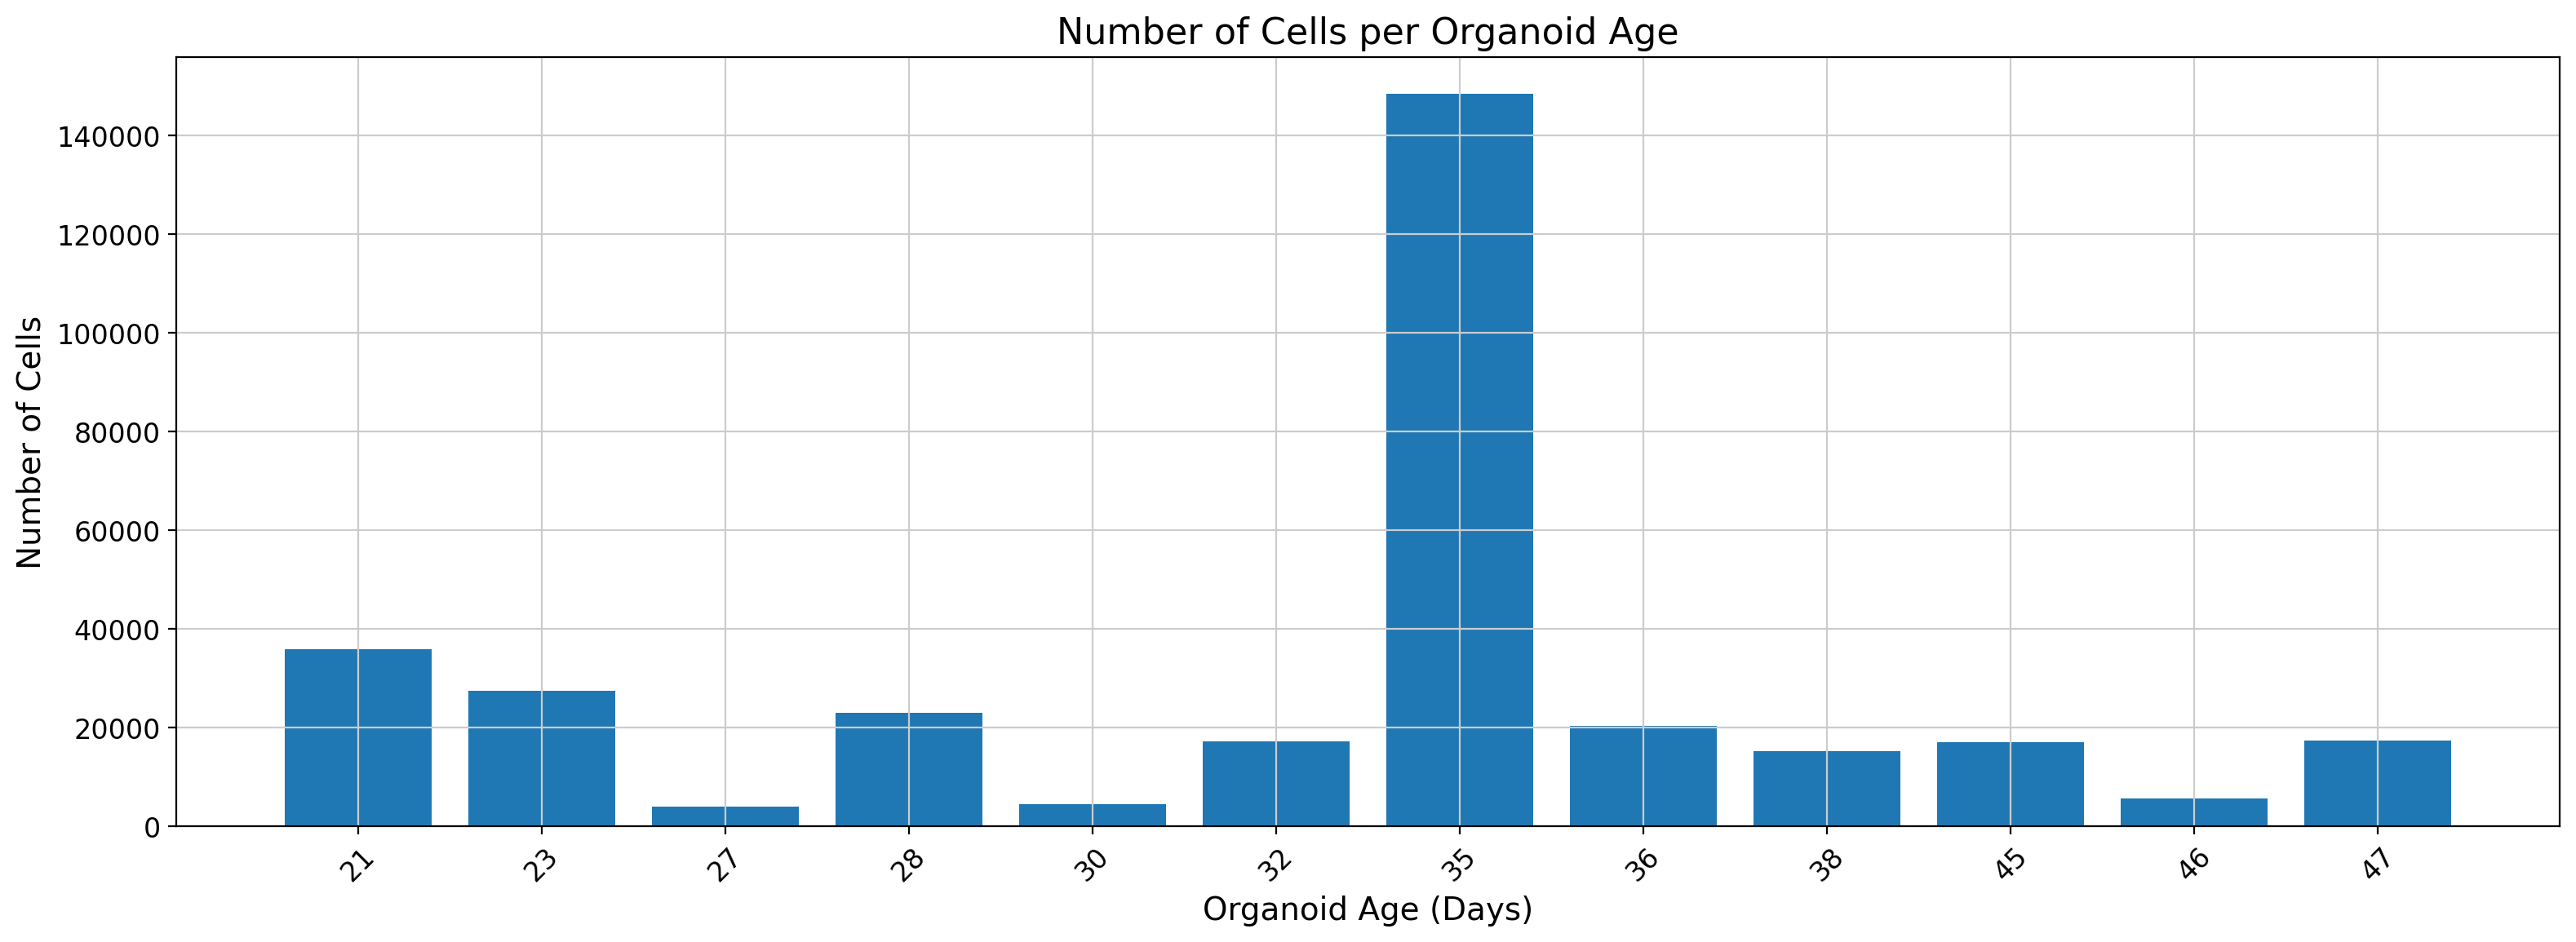

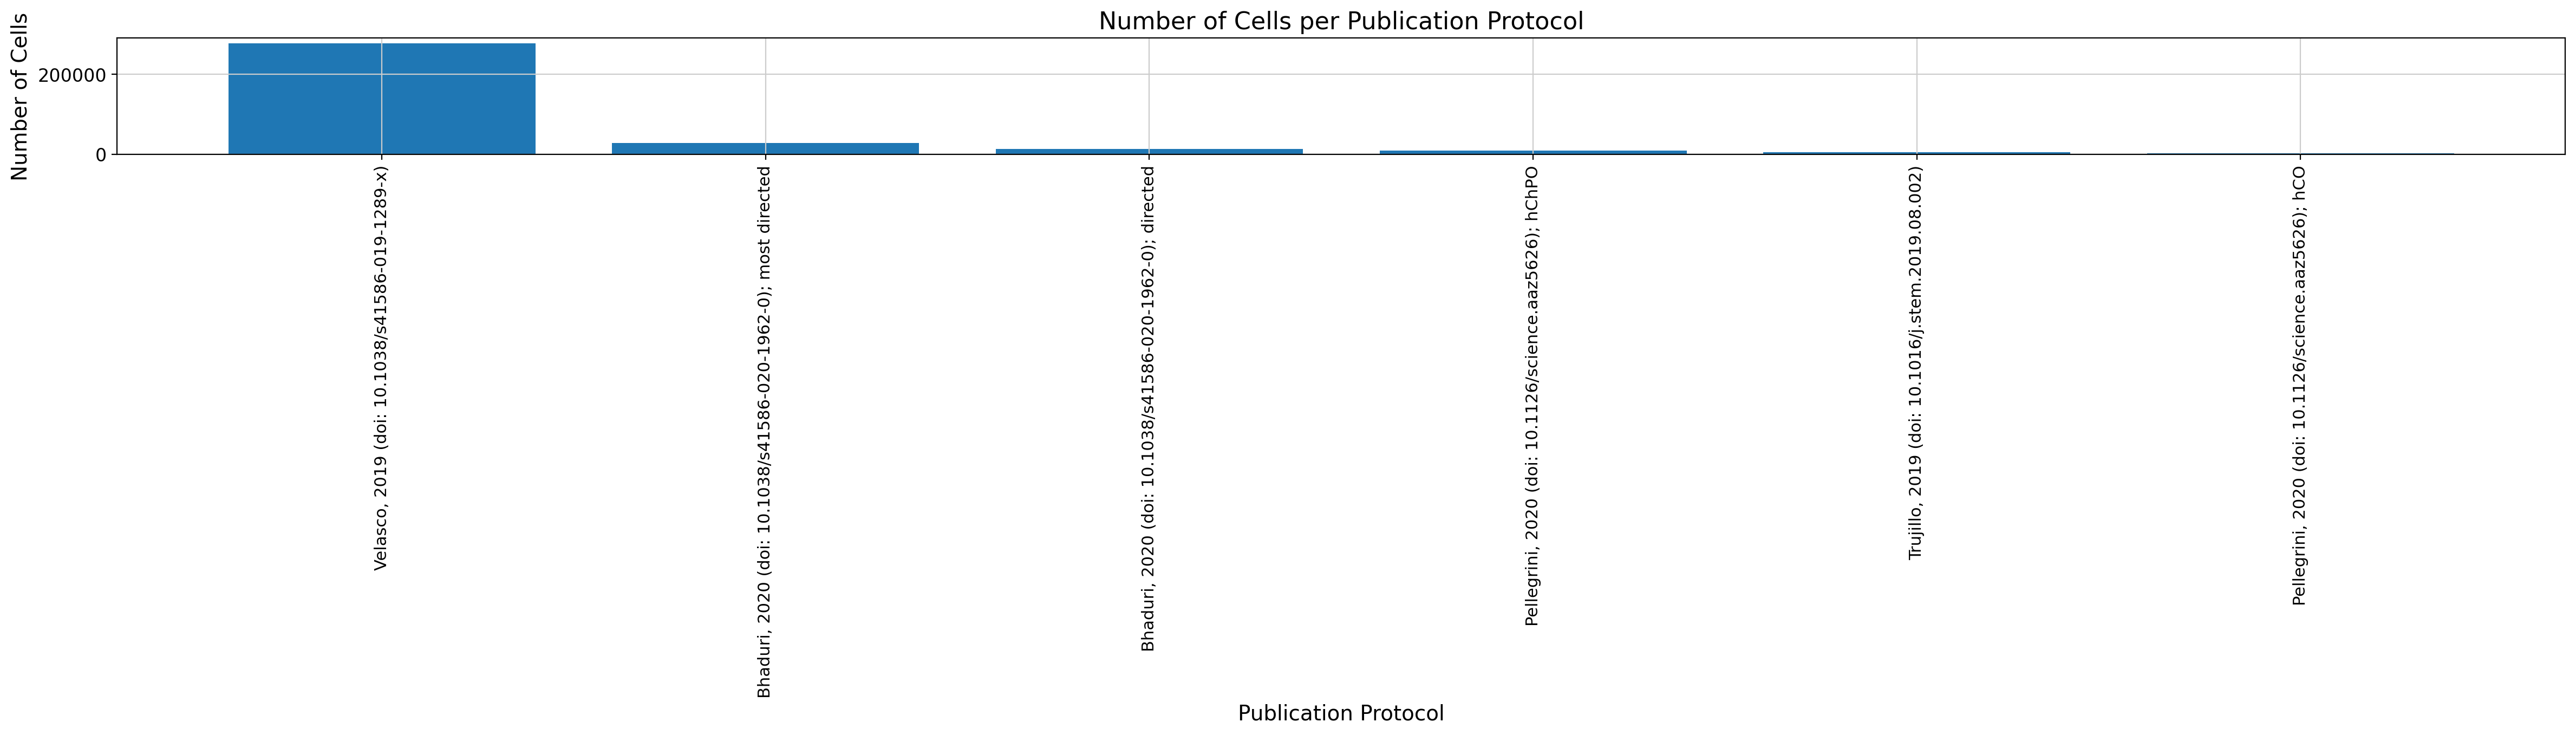

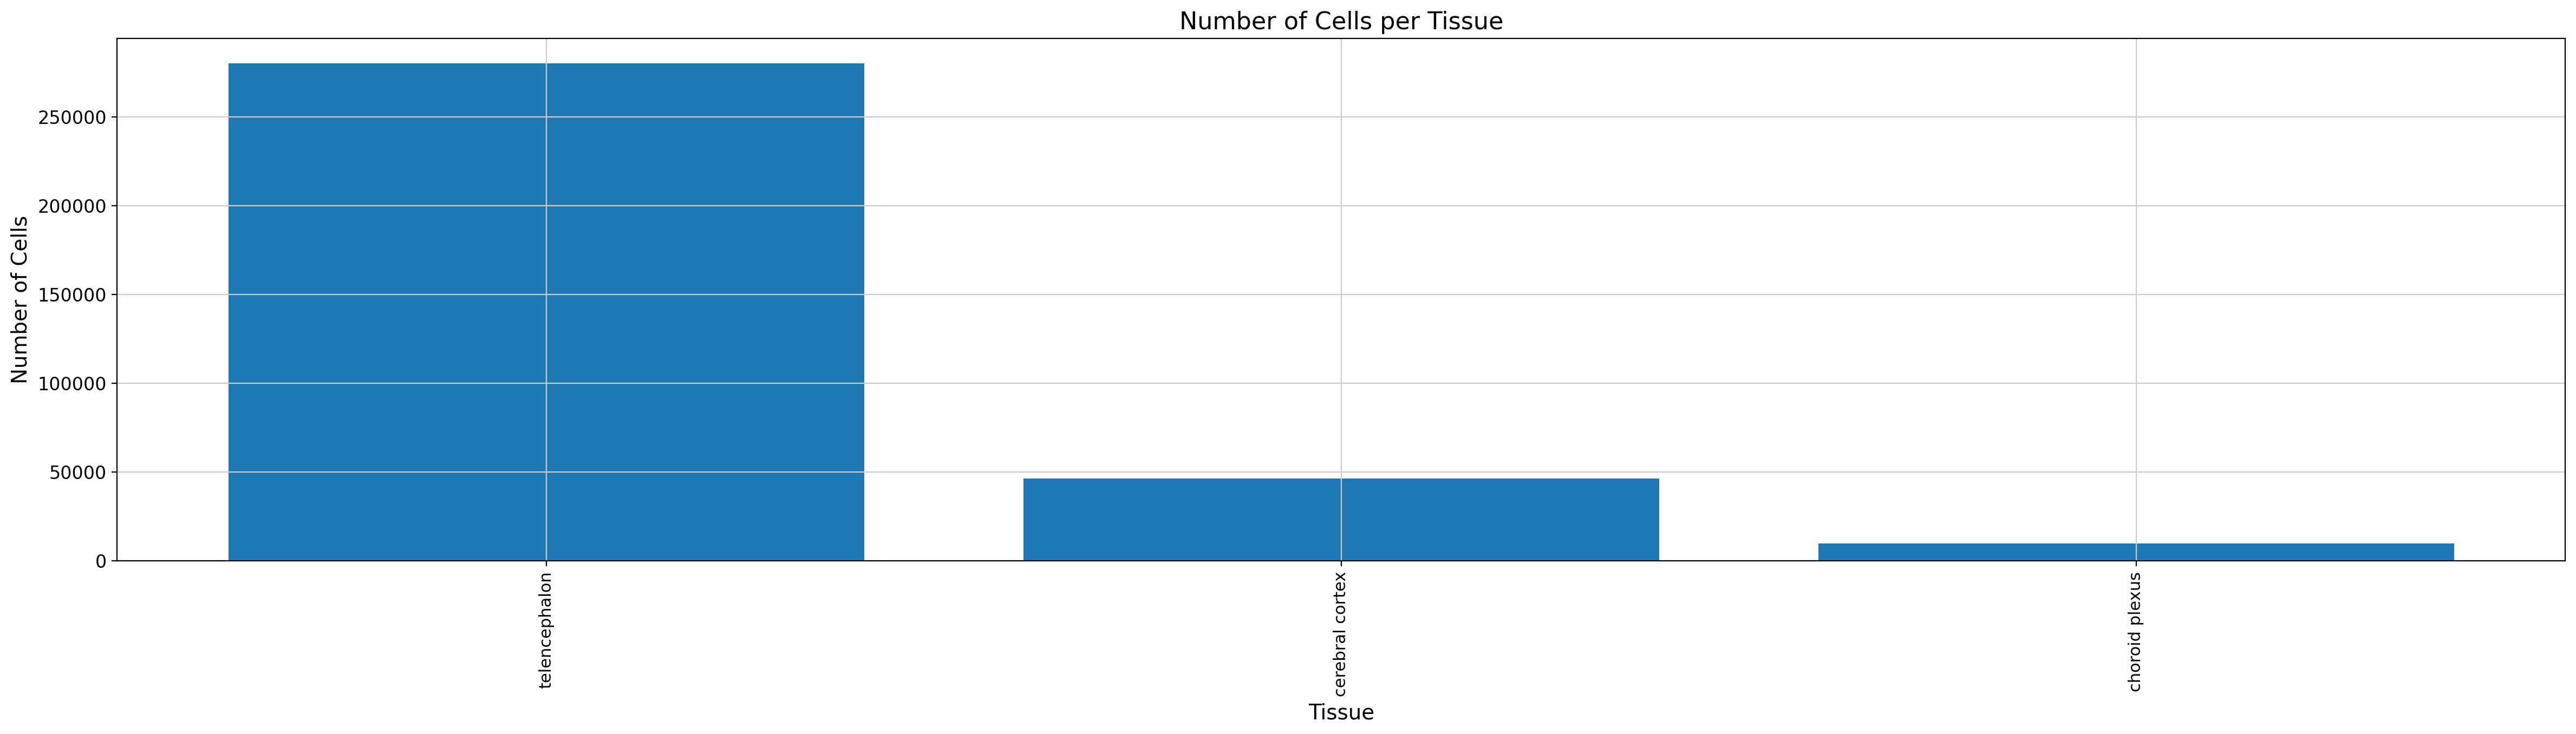

In [53]:
# ---- Barplot 1: Number of cells per organoid age ----
age_counts = (
    adata_complete[mask_author & mask_age].obs['organoid_age_days']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 6))  # wider
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.xlabel("Organoid Age (Days)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Organoid Age", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


# ---- Barplot 2: Number of cells per publication protocol ----
protocol_counts = (
    adata_complete[mask_author & mask_age].obs['assay_differentiation']
    .value_counts()
)

plt.figure(figsize=(24, 7))  # much wider
plt.bar(protocol_counts.index.astype(str), protocol_counts.values)
plt.xlabel("Publication Protocol", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Publication Protocol", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# ---- Barplot 3: Number of cells per tissue ----
tissue_counts = (
    adata_complete[mask_author & mask_age].obs['tissue']
    .value_counts()
)

plt.figure(figsize=(24, 7))  # much wider
plt.bar(tissue_counts.index.astype(str), tissue_counts.values)
plt.xlabel("Tissue", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Tissue", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Some of the protocols were lost with the filtering by organoids age, e.g. Pasca like is it possible to see:

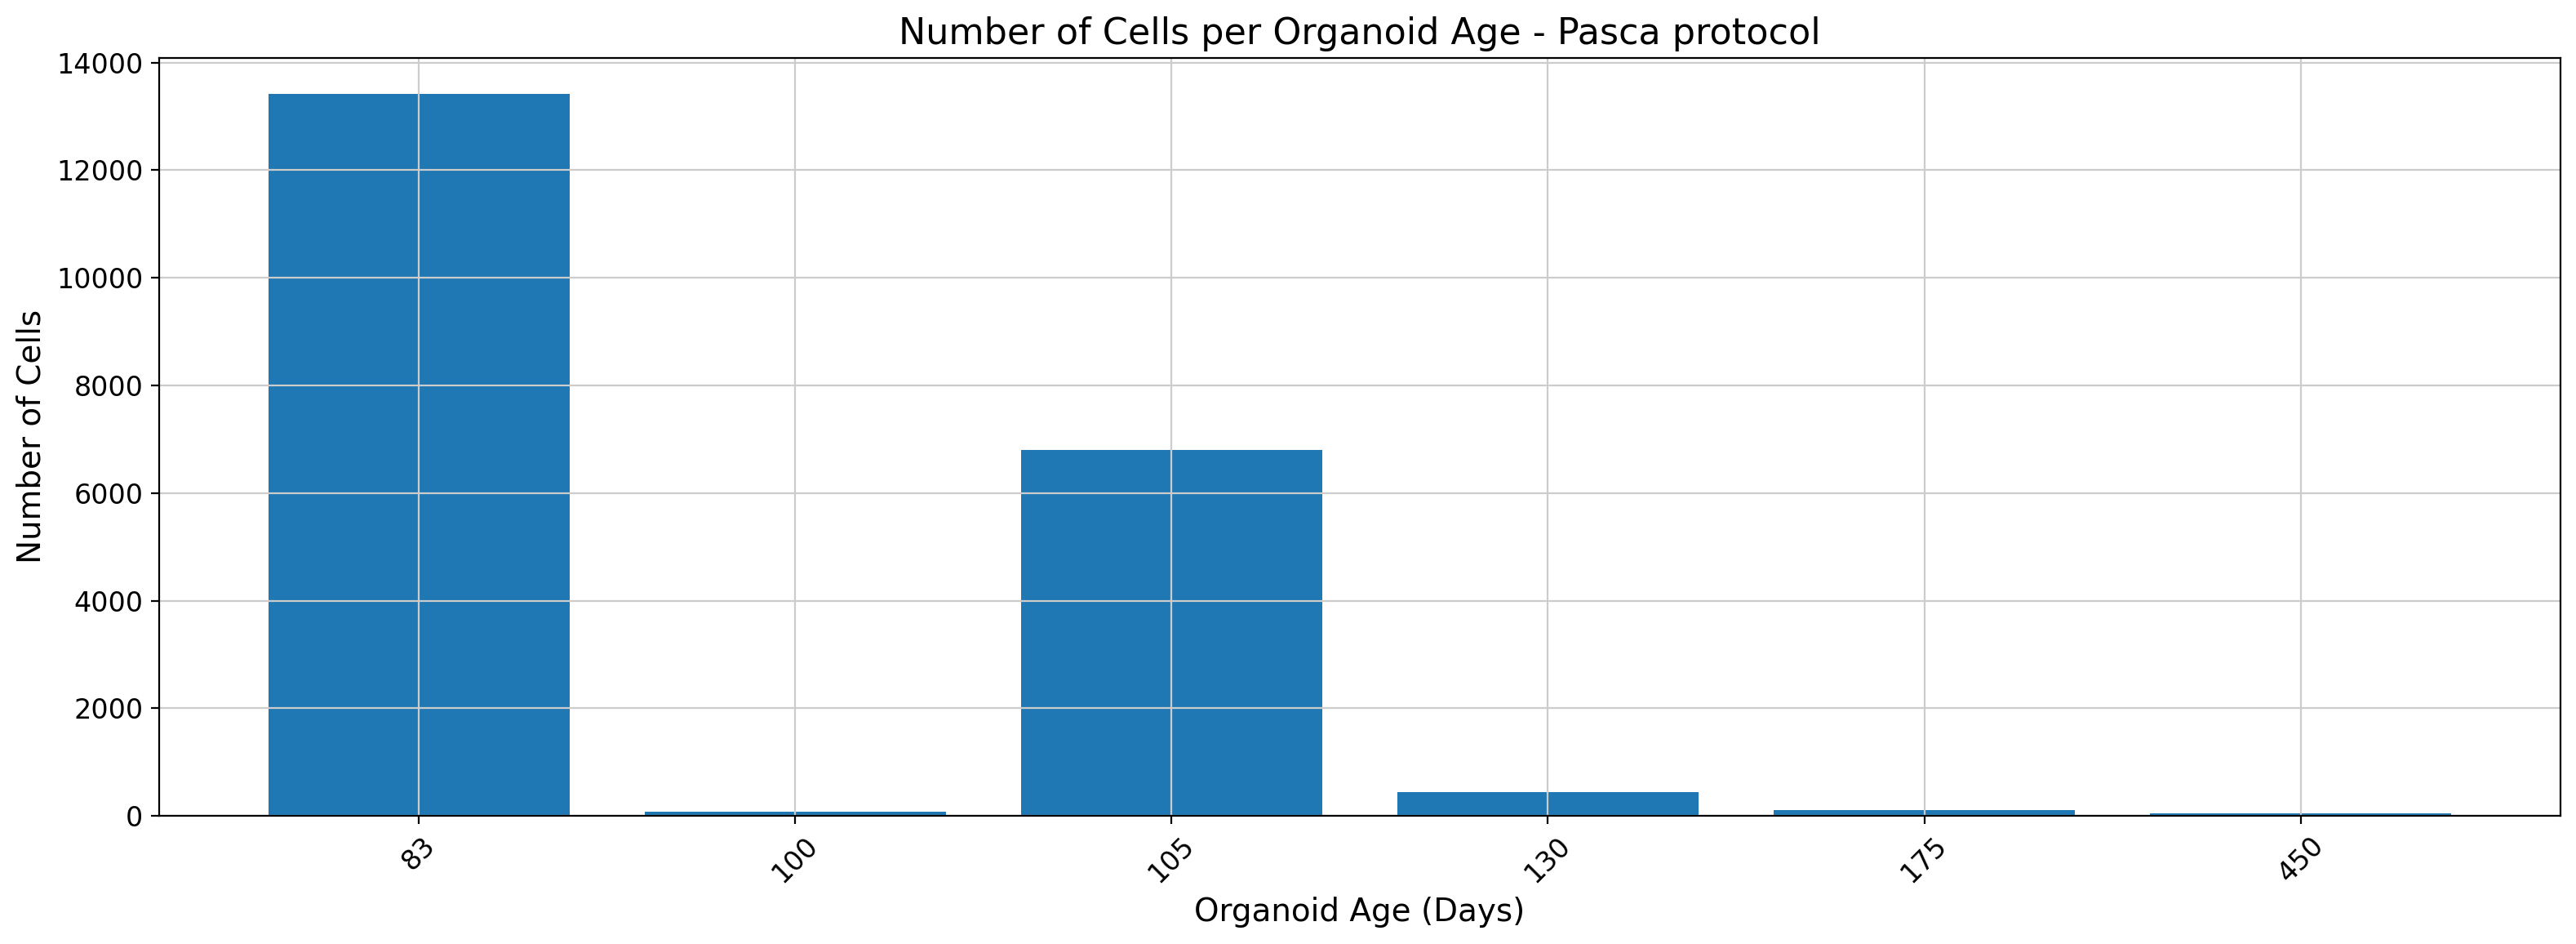

In [54]:
mask_Pasca = adata_complete.obs["assay_differentiation"].str.contains("Pasca", na=False)

age_counts = (
    adata_complete[mask_Pasca].obs['organoid_age_days']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 6))  # wider
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.xlabel("Organoid Age (Days)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Organoid Age - Pasca protocol", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Filtering by both protocol and age of organoids + tissue = "cerabral cortex"

In [57]:
mask_tissue = adata_complete.obs["tissue"].str.contains("cerebral cortex")
adata_complete.obs[mask_author & mask_age & mask_tissue]

,assay_differentiation,assay_type_differentiation,bio_sample,cell_line,cell_type_original,gm,id,individual,state_exact,suspension_type,...,cell_type_ontology_term_id,is_primary_data,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
new_index,,,,,,,,,,,,,,,,,,,,,
homosapiens_None_2020_10x3v2_bhaduriaparna_001_d10_1038_s41586_020_1962_0_2_H28126XWeek5_CGAGAAGCACGAAGCA,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,custom_H28126,Excitatory Neuron_Pan-neuronal,unknown,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,unknown,unknown,cell,...,CL:0000679,True,glutamatergic neuron,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,P<-*kQg=GU
homosapiens_None_2020_10x3v2_bhaduriaparna_001_d10_1038_s41586_020_1962_0_11_H28126XWeek5_GCGCGATGTTTGCATG,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,custom_H28126,Radial Glia_Glycolytic RG,unknown,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,unknown,unknown,cell,...,CL:0000681,True,radial glial cell,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,|1}k6aZWxK
homosapiens_None_2020_10x3v2_bhaduriaparna_001_d10_1038_s41586_020_1962_0_62_H28126XWeek5_TGGGCGTCAGCGTCCA,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,custom_H28126,Radial Glia_Pan-radial glia,unknown,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,unknown,unknown,cell,...,CL:0000681,True,radial glial cell,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,cS409x?OB7
homosapiens_None_2020_10x3v2_bhaduriaparna_001_d10_1038_s41586_020_1962_0_64_H28126XWeek5_ACAGCCGAGTTAACGA,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,custom_H28126,Radial Glia_Hindbrain RG,unknown,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,unknown,unknown,cell,...,CL:0000681,True,radial glial cell,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,vMA|@gFJwJ
homosapiens_None_2020_10x3v2_bhaduriaparna_001_d10_1038_s41586_020_1962_0_120_H28126XWeek5_ACCAGTAGTGTCAATC,"Bhaduri, 2020 (doi: 10.1038/s41586-020-1962-0)...",guided,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,custom_H28126,Radial Glia_Pan-radial glia,unknown,homosapiens_None_2020_10x3v2_bhaduriaparna_001...,unknown,unknown,cell,...,CL:0000681,True,radial glial cell,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,>adXpfOd|c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
homosapiens_cerebralcortex_2019_10x3v2_trujillocleber_001_d10_1016_j_stem_2019_08_002_4826_TTTGTCACAATGTAAG-1,"Trujillo, 2019 (doi: 10.1016/j.stem.2019.08.002)",guided,unknown,unknown,unknown,unknown,homosapiens_cerebralcortex_2019_10x3v2_trujill...,unknown,unknown,cell,...,unknown,True,unknown,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,aCWAuk2C05
homosapiens_cerebralcortex_2019_10x3v2_trujillocleber_001_d10_1016_j_stem_2019_08_002_4827_TTTGTCACAGCGATCC-1,"Trujillo, 2019 (doi: 10.1016/j.stem.2019.08.002)",guided,unknown,unknown,unknown,unknown,homosapiens_cerebralcortex_2019_10x3v2_trujill...,unknown,unknown,cell,...,unknown,True,unknown,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,2~!ndBKC|;
homosapiens_cerebralcortex_2019_10x3v2_trujillocleber_001_d10_1016_j_stem_2019_08_002_4830_TTTGTCAGTATATGGA-1,"Trujillo, 2019 (doi: 10.1016/j.stem.2019.08.002)",guided,unknown,unknown,unknown,unknown,homosapiens_cerebralcortex_2019_10x3v2_trujill...,unknown,unknown,cell,...,unknown,True,unknown,10x 3' v2,normal,male,cerebral cortex,unknown,unknown,4+l4OnHG2I


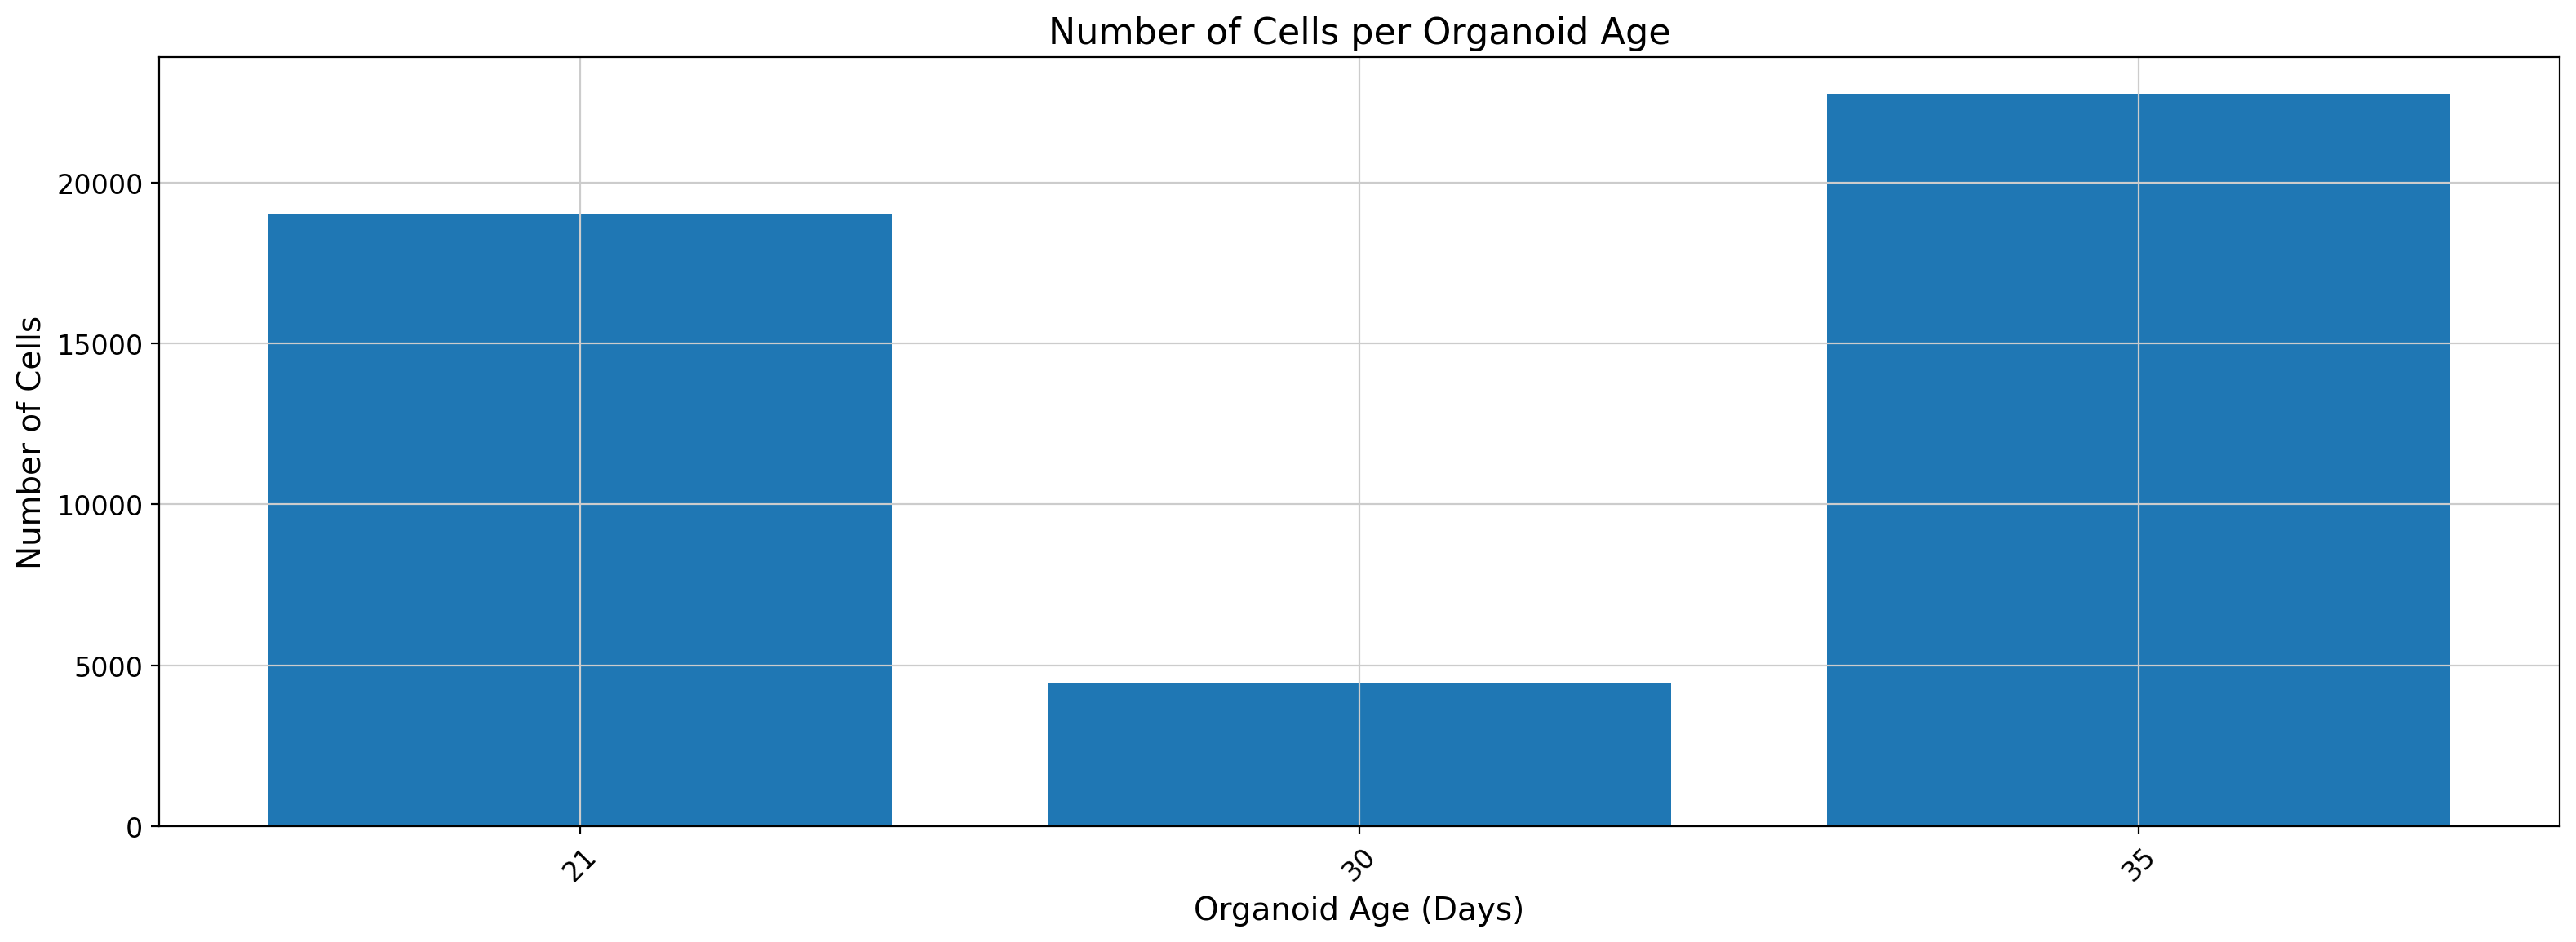

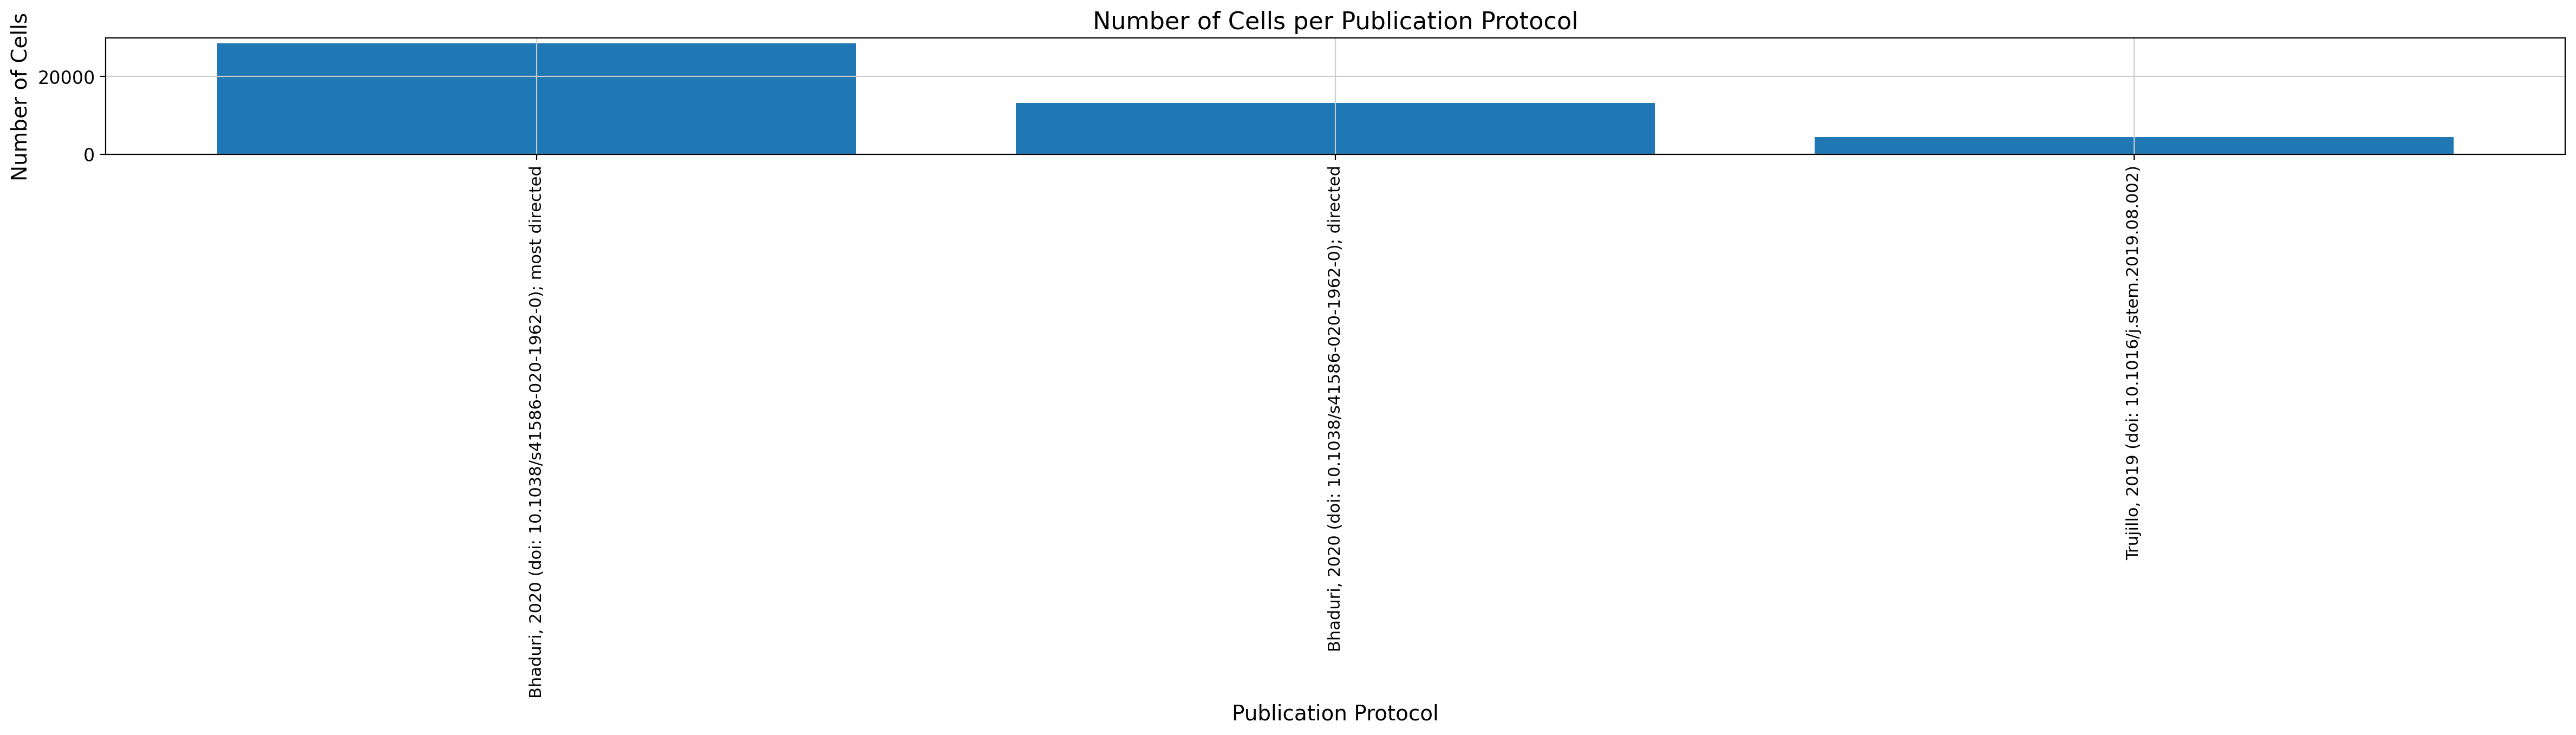

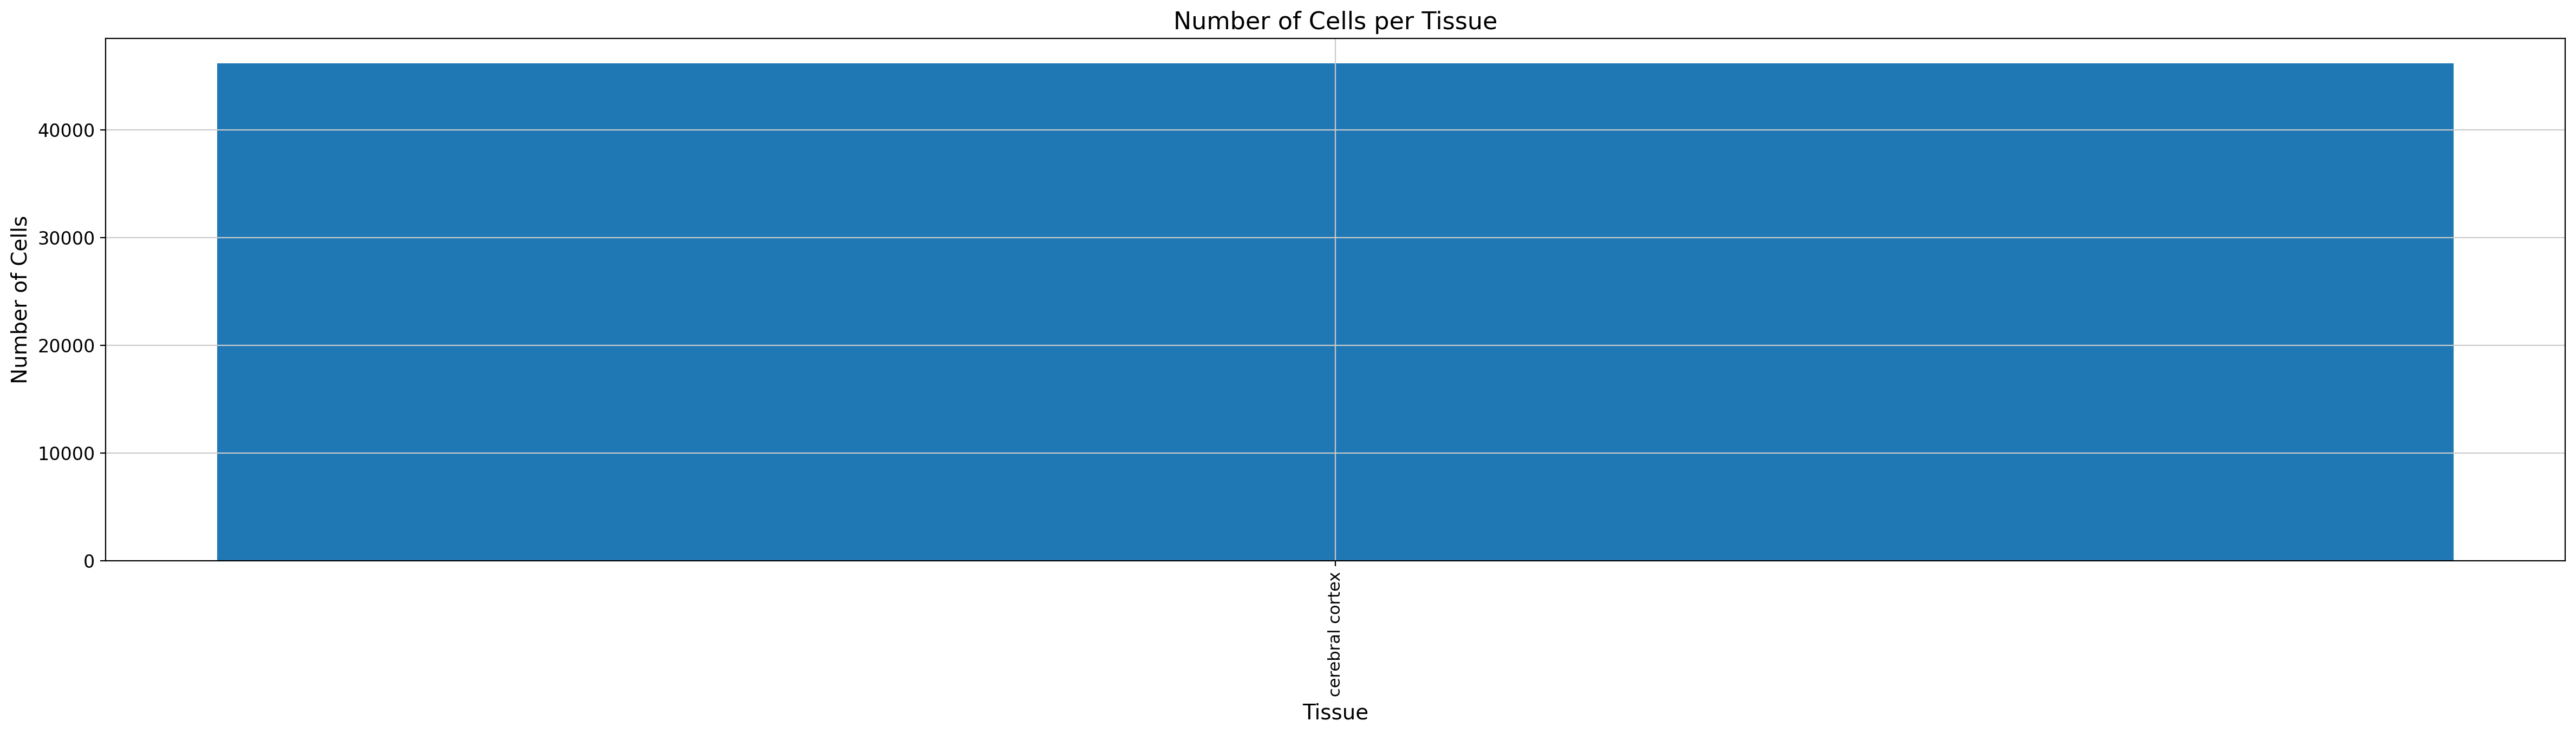

In [44]:
# ---- Barplot 1: Number of cells per organoid age ----
age_counts = (
    adata_complete[mask_author & mask_age & mask_tissue].obs['organoid_age_days']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 6))  # wider
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.xlabel("Organoid Age (Days)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Organoid Age", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


# ---- Barplot 2: Number of cells per publication protocol ----
protocol_counts = (
    adata_complete[mask_author & mask_age & mask_tissue].obs['assay_differentiation']
    .value_counts()
)

plt.figure(figsize=(24, 7))  # much wider
plt.bar(protocol_counts.index.astype(str), protocol_counts.values)
plt.xlabel("Publication Protocol", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Publication Protocol", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# ---- Barplot 3: Number of cells per tissue ----
tissue_counts = (
    adata_complete[mask_author & mask_age & mask_tissue].obs['tissue']
    .value_counts()
)

plt.figure(figsize=(24, 7))  # much wider
plt.bar(tissue_counts.index.astype(str), tissue_counts.values)
plt.xlabel("Tissue", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Number of Cells per Tissue", fontsize=16)
plt.xticks(rotation=90, fontsize=11)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [55]:
adata_protocol_age = adata_complete[mask_author & mask_age].copy()

In [56]:
adata_protocol_age

AnnData object with n_obs × n_vars = 336027 × 35725
    obs: 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type_original', 'gm', 'id', 'individual', 'state_exact', 'suspension_type', 'tech_sample', 'treatment', 'organoid_age_days', 'publication', 'doi', 'batch', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis', 'hnoca_core', 'annot_level_2_extended', 'tissue_type', 'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_length', 'highly_variable', 'highly_variable_rank', 'highly_variable_nbatches', 'feature_is_filtered', 'feature_name',

In [58]:
adata_protocol_age_tissue = adata_complete[mask_author & mask_age & mask_tissue].copy()
adata_protocol_age_tissue

AnnData object with n_obs × n_vars = 46221 × 35725
    obs: 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type_original', 'gm', 'id', 'individual', 'state_exact', 'suspension_type', 'tech_sample', 'treatment', 'organoid_age_days', 'publication', 'doi', 'batch', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis', 'hnoca_core', 'annot_level_2_extended', 'tissue_type', 'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_length', 'highly_variable', 'highly_variable_rank', 'highly_variable_nbatches', 'feature_is_filtered', 'feature_name', 

## 3. Savings

In [59]:
print(datetime.now())

2026-03-05 16:04:03.561061


In [60]:
adata_protocol_age.write("../../../../DataDir/ExternalData/SingleCellData/HNOCA_protocol_age.h5ad")

In [61]:
adata_protocol_age_tissue.write("../../../../DataDir/ExternalData/SingleCellData/HNOCA_protocol_age_tissue.h5ad")